In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
from natsort import natsorted
from PIL import Image
from torch.utils.data import TensorDataset, DataLoader

def create_gif(pth, time_ind):
    #files = glob.glob(r"./imgs/*.png")
    files = glob.glob(os.path.join(pth,'*.png'))
    files = natsorted(files)
    image_array = []
    
    def update(i):
        im.set_array(image_array[i])
        return im, 
    
    for my_file in files:

        image = Image.open(my_file)
        image_array.append(image)
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=100, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    #animation_fig.save("./imgs/animated_{}.gif".format(time_ind))
    animation_fig.save(os.path.join(pth,'animated_{}.gif').format(time_ind))
    pass

### Adding gamma_0 value for SINR computation ####

$\gamma = \frac{|h|_s^2P_t}{|h|_i^2P_t + N_0B}$

Assuming power transmitted power is same from all BSs then we have 

$\gamma = \frac{|h|_s^2}{|h|_i^2 + \frac{1}{\gamma_0}}$


where $\gamma_0 = P_t/N_0B$, you can assume P_t = 10 dBm, and the below calculations for $N_0$

In [2]:
## transmit power ###
Pt_dBm = 10  # Transmit power in dBm

#### Noise power ####
k = 1.38e-23  # Boltzmann's constant
T = 290       # Temperature in Kelvin
B = 10e6       # Bandwidth in Hz

# Calculate noise spectral density in Watts/Hz
Noise_spectral_density = k * T

# Convert noise spectral density to dBm/Hz
# Convert to Watts first then to dBm (1 mW = 0.001 W)
Noise_spectral_density_W = Noise_spectral_density * 1000  # Convert to mW
Noise_spectral_density_dBm = 10 * np.log10(Noise_spectral_density_W)
print('Noise_spectral_density_dBm', Noise_spectral_density_dBm)

# Calculate total noise power in Watts then convert to dBm
N_thermal = Noise_spectral_density * B  # Total noise power in Watts
N_thermal_dBm = 10 * np.log10(N_thermal * 1000)  # Convert noise power to dBm
print('thermal_noise_power(dBm)', N_thermal_dBm)

##### gamma_0 in dB ############
gamma_0_dB = Pt_dBm - N_thermal_dBm  # Calculate SNR in dB
#print('gamma_0 (dB)', gamma_0_dB)

##### gamma_0 ######
gamma_0 = np.power(10, gamma_0_dB/10)
print('1/gamma_0', 1/gamma_0)

Noise_spectral_density_dBm -173.97722915699805
thermal_noise_power(dBm) -103.97722915699808
1/gamma_0 4.001999999999999e-12


### 
CDF of SINR computed for F($\gamma$), for different channel realizations,
below is when the the device is at a mean distance of 1m from the serving BS with a standard deviation of 0.1 m, and mean distance from the interfering BS at 4 meters with std of 0.1m 

In [3]:
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

In [4]:
############## Creating distances intra and inter ########
M = 5 # number of sub-networks 
Ts = 10000 # number of time slots
J = 3 # number of devices
f_c = 1.3 #GHz
N = 4
TxRxds = np.zeros((Ts, M, M*J))
d_intra = np.abs(np.random.normal(0.5,0.1,M*J))
d_intra = np.reshape(d_intra, (M,J))

In [5]:
def generate_random_point(grid_size):
    return np.random.uniform(0, grid_size, 2)

def generate_random_velocity():
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11  # 40 km/h in m/s
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def is_within_grid(point, grid_size):
    return all(0 <= coord <= grid_size for coord in point)

def handle_boundary_collisions(point, grid_size):
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11
    if point[0] <= 0 or point[0] >= grid_size:
        angle = np.pi - angle if point[0] <= 0 else -angle
    if point[1] <= 0 or point[1] >= grid_size:
        angle = -np.pi / 2 - angle if point[1] <= 0 else np.pi / 2 - angle
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def handle_ap_collisions(points, velocities, min_distance):
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if np.linalg.norm(points[i] - points[j]) < min_distance:
                # Adjust direction randomly for both APs
                velocities[i] = generate_random_velocity()
                velocities[j] = generate_random_velocity()
    return velocities

def update_positions(points, velocities, tau, grid_size, min_distance):
    new_points = points + velocities * tau
    for i, point in enumerate(new_points):
        if not is_within_grid(point, grid_size):
            velocities[i] = handle_boundary_collisions(point, grid_size)
        new_points[i] = points[i] + velocities[i] * tau  # Recalculate with new velocity
    velocities = handle_ap_collisions(new_points, velocities, min_distance)
    return new_points, velocities

# Initialize parameters
grid_size = 20
num_points = M
min_distance = 2
tau = 0.01  # time interval in seconds

# Initialize points and velocities
points = np.array([generate_random_point(grid_size) for _ in range(num_points)])
velocities = np.array([generate_random_velocity() for _ in range(num_points)])
init_cents = points
# Simulation loop for 20 time steps
pth = r'C:\Users\sriniva3\OneDrive - Aalto University\Simulations\RL framework URLLC\RL framework_V2.0_DDPG\imgs'
#Ts = 1000
sub_net_cents = np.zeros((Ts+1, num_points, 2))
sub_net_cents[0] = init_cents
for step in tqdm(range(Ts-1)):
    points, velocities = update_positions(points, velocities, tau, grid_size, min_distance)
    sub_net_cents[step+1] = points
    '''
    # Plotting for visualization
    plt.figure(figsize=(3, 3))
    plt.scatter(points[:, 0], points[:, 1], c='red', label=f'Time Step {step+1}')
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title(f'Access Points at Step {step+1}')
    plt.xlabel('Meters')
    plt.ylabel('Meters')
    #plt.legend()
    plt.savefig(os.path.join(pth, '{}.png'.format(step)))
    plt.close()
    #plt.show()
    ''';
#create_gif(pth, step)

100%|███████████████████████████████████████████████████████████████████████████| 9999/9999 [00:00<00:00, 11746.19it/s]


In [6]:
d_relative_locs = {}
for i in range(M):
    d_angle = np.random.uniform(0,2*np.pi,J) 
    d_r = np.random.uniform(0, 1, J)
    d_relative_locs[i] = np.vstack([d_r*np.cos(d_angle), d_r*np.sin(d_angle)])

In [7]:
def return_euclid_dist(device_x_coord, device_y_coord, AP_x_coord, AP_y_coord):
    device_coords = np.array([device_x_coord, device_y_coord])
    AP_coords = np.array([AP_x_coord, AP_y_coord])
    return np.linalg.norm(device_coords - AP_coords)

x_coords_ts, y_coords_ts = {}, {}
for ts in range(Ts):
    coords = sub_net_cents[ts]
    point_xs, point_ys = [], []
    for k in d_relative_locs.keys():
        point_x = d_relative_locs[k][0] + coords[k][0]
        point_y = d_relative_locs[k][1] + coords[k][1]
        #print(point_x, point_y)
        point_xs.append(point_x)
        point_ys.append(point_y)
    #break    
    x_coords_ts[ts] = point_xs
    y_coords_ts[ts] = point_ys

In [8]:
TxRxds = np.zeros((Ts, M, M*J))
for ts in range(Ts):
    device_x_coords, device_y_coords = np.array(x_coords_ts[ts]), np.array(y_coords_ts[ts])
    device_x_coords, device_y_coords = device_x_coords.flatten(), device_y_coords.flatten()
    AP_x_coords, AP_y_coords = sub_net_cents[ts][:,0], sub_net_cents[ts][:,1]
    
    #for dx in device_x_coords 
    dists = np.zeros((M,M*J))
    for i in range(AP_x_coords.shape[0]):
        dist = []
        for j in range(len(device_x_coords.flatten())):
            #dist = []
            #print(i,j)
            dist.append(return_euclid_dist(device_x_coords[j], device_y_coords[j], AP_x_coords[i], AP_y_coords[i]))
            #print(dist)
        dists[i] = np.array(dist)
    TxRxds[ts] = dists
    #break

#dist = return_euclid_dist(x_coords_ts[0], y_coords_ts[0], AP_x_coord, AP_y_coord)

(array([175710.,  75311., 104647., 103304.,  98551.,  85576.,  49340.,
         32442.,  20979.,   4140.]),
 array([1.98693155e-02, 3.35502145e+00, 6.69017358e+00, 1.00253257e+01,
        1.33604778e+01, 1.66956300e+01, 2.00307821e+01, 2.33659342e+01,
        2.67010864e+01, 3.00362385e+01, 3.33713906e+01]),
 <BarContainer object of 10 artists>)

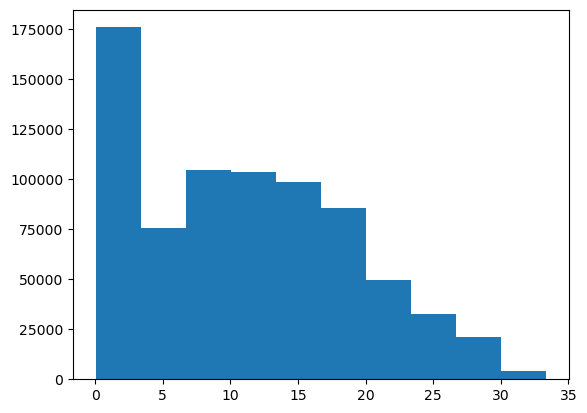

In [9]:
plt.hist(TxRxds.flatten())

In [10]:
TxRxds.shape

(10000, 5, 15)

### Using Jakes model 

In [11]:

def return_jakes_coeffcients(fd_max, TimeVaris, n_links = 5, plot = True):
    ff_gains, TimeSequences = [], []
    rays = 100
    for i in tqdm(range(n_links)):    
        #TimeVaris = np.arange(0,50,0.0005)
        #TimeVaris = np.arange(0,.2,0.005)
        frequs = np.sort(np.array([np.round(fd_max*np.cos(2*np.pi*np.random.uniform(0,1))) for _ in range(rays)]))
        phases = np.array([np.exp(1j*2*np.pi*np.random.uniform(0,1)) for _ in range(rays)])

        TimeSequence = []
        for t in TimeVaris:
            tab = np.exp(1j*2*np.pi*frequs*t)
            tabrot = tab*phases
            fun = np.sum(tabrot)
            TimeSequence.append(fun)
        TimeSequence = np.array(TimeSequence)

        #TimeSequence = TimeSequence/np.linalg.norm(TimeSequence)*np.sqrt(len(TimeSequence))
        PowerSequence1 =  np.abs(TimeSequence)**2;
        #plt.plot(TimeVaris[0:200], 10*np.log10(PowerSequence1)[0:200])
        ff_gains.append(PowerSequence1)
        TimeSequences.append(TimeSequence)
    ff_gains = np.array(ff_gains)/rays
    TimeSequences = np.array(TimeSequences)
    if plot:
        plt.plot(TimeVaris[0:200], 10*np.log10(ff_gains[0])[0:200])
        plt.show()
    return ff_gains, TimeSequences

v = 40 #kmph 
v_ms = v*5/18
c = 3*1e8
tau = .01
fd_max = v_ms*f_c*1e9/c
TimeVaris = np.arange(0,5,5/Ts)

ff_gains, TimeSequences = return_jakes_coeffcients(fd_max, TimeVaris, n_links = M*(M-1)*J*N, plot = False)
ff_gains_intra, _ = return_jakes_coeffcients(fd_max, TimeVaris, n_links = M*J*N, plot = False)

#plt.plot(TimeVaris[0:Ts], 10*np.log10(ff_gains.flatten()[0:Ts]))
#plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:14<00:00,  4.10it/s]


In [12]:
ff_gains_intra.shape

(60, 10000)

In [13]:
'''
K_intra    = 4.0
LOS_scale  = np.sqrt(K_intra/(K_intra+1))
NLOS_scale = np.sqrt(1/(K_intra+1))

phi_los = np.exp(1j*2*np.pi*np.random.rand(M, J, N))
h_los   = LOS_scale * phi_los                      
h_los = np.expand_dims(h_los, axis=3)      # shape → (M, J, N, 1)
h_los= np.repeat(h_los, Ts, axis=3)  # shape → (M, J, N, Ts)
h_los = h_los.reshape(M*J*N, Ts)
h_nlos  = NLOS_scale * np.sqrt(ff_gains_intra)  
h_intra_ts = h_los + h_nlos
h_intra_abs_ts = np.abs(h_intra_ts)**2
h_intra_abs_ts_db = 10*np.log10(h_intra_abs_ts)
plt.plot(h_intra_abs_ts_db[2].flatten()[0:1000])
#plt.plot(10*np.log10(ff_gains_intra[2].flatten()[0:1000]))
plt.show()
''';

In [14]:
#np.save( 'working_ff_gains.npy',ff_gains)
#ff_gains = np.load('ff_gains_3000.npy')

In [15]:
# Assuming ff_gains_intra (shape: M*J*N × Ts) and ff_gains (shape: M*(M-1)*J*N × Ts) exist,
# and TxRxds is shape (Ts, M, M*J)

# Rician K‐factor for intra‐subnet links
K_intra    = 4.0
LOS_scale  = np.sqrt(K_intra/(K_intra+1))
NLOS_scale = np.sqrt(1/(K_intra+1))

# Precompute link‐ID maps
intra_link_ids  = np.arange(M*J*N).reshape(M, J, N)
interf_link_ids = np.arange(M*(M-1)*J*N).reshape(M, M-1, J, N)

all_SINRsdB             = np.zeros((Ts, M, J, N))
alltime_WantedSigPerDev = []
alltime_InterfPowsPerDev= []
all_gains_intra_dB = np.zeros((Ts,M,J,N))
for ts in range(Ts):
    # 1) Intra‐subnet Rician fading power gains (M, J, N)
    G_intra = ff_gains_intra[intra_link_ids, ts]       # (M, J, N)
    h_nlos  = NLOS_scale * np.sqrt(G_intra)            # (M, J, N)
    phi_los = np.exp(1j*2*np.pi*np.random.rand(M, J, N))
    h_los   = LOS_scale * phi_los                      # (M, J, N)
    H_intra = h_los + h_nlos                           # (M, J, N)
    Gains_intra = np.abs(H_intra)**2                   # (M, J, N)
    all_gains_intra_dB[ts,:,:,:] = 10 * np.log10(Gains_intra)
    # 2) Interferer Jakes‐power (no LOS) (M, M-1, J, N)
    G_interf_flat = ff_gains[:, ts]                    # (M*(M-1)*J*N)
    G_interf      = G_interf_flat.reshape(M, M-1, J, N)

    # 3) Assemble full fast‐fading matrix (M, M*J, N)
    all_fast_fading_gains = np.zeros((M, M*J, N))
    for m in range(M):
        intra_block = Gains_intra[m]                   # (J, N)
        interf_block= G_interf[m].reshape((M-1)*J, N)  # ((M-1)*J, N)
        all_fast_fading_gains[m] = np.vstack([intra_block, interf_block])

    # 4) Full path‐loss for AP→all devices (M, M*J)
    PL_los_full  = 31.84 +21.5*np.log10(TxRxds[ts]) + 19*np.log10(f_c)
    PL_nlos_full = 33    +25.5*np.log10(TxRxds[ts])+ 20*np.log10(f_c)
    PL_full      = np.maximum(PL_los_full, PL_nlos_full)
    Beta_full    = 10**(-PL_full/10)                   # (M, M*J)
    PathGains_full = Beta_full[:,:,None] * np.ones((1,1,N))  # (M, M*J, N)

    # 5) Combine path‐loss & fast fading
    PathGainsTot = PathGains_full * all_fast_fading_gains     # (M, M*J, N)

    # 6) Split wanted vs. interferers and compute SINR
    WantedSig  = np.zeros((M, J, N))
    InterfPow  = np.zeros((M, J, N))
    for m in range(M):
        WantedSig[m] = PathGainsTot[m, m*J:(m+1)*J, :]
        mask = np.ones(M*J, bool)
        mask[m*J:(m+1)*J] = False
        InterfPow[m] = PathGainsTot[m, mask, :].sum(axis=0)

    SINR_lin        = WantedSig / (InterfPow + 1/gamma_0)
    all_SINRsdB[ts] = 10*np.log10(SINR_lin)

    alltime_WantedSigPerDev .append(WantedSig)
    alltime_InterfPowsPerDev.append(InterfPow)

alltime_WantedSigPerDev   = np.array(alltime_WantedSigPerDev)
alltime_InterfPowsPerDev  = np.array(alltime_InterfPowsPerDev)


24.00799481173322


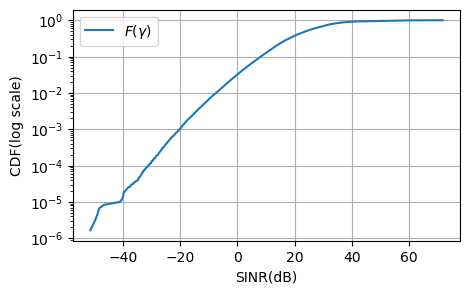

In [16]:
#all_SINRsdB = np.load('working_all_SINRsdB.npy')
a1, cdf1 = return_cdf(all_SINRsdB.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(all_SINRsdB.flatten()))

In [17]:
ff_gains_intra.shape

(60, 10000)

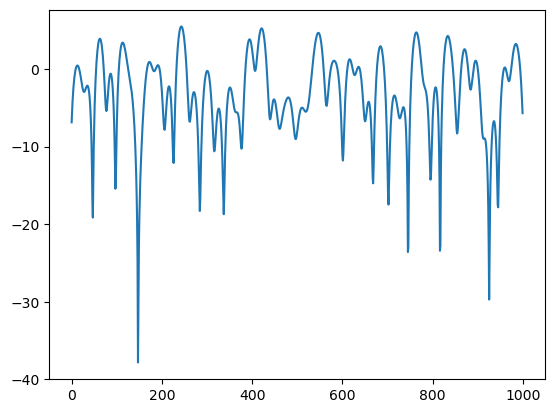

In [18]:
plt.plot(10*np.log10(ff_gains_intra[2].flatten()[0:1000]))
plt.show()

In [19]:
'''
alltime_SINRsdB_combined = []
all_SINRslin = np.power(10, all_SINRsdB/10)
for ts in range(all_SINRsdB.shape[0]):
    vals = all_SINRslin[ts,:,:,:]
    SINRS_combined = np.min(vals, axis = 2)
    SINRsdB_combined = 10*np.log10(SINRS_combined)
    alltime_SINRsdB_combined.append(SINRsdB_combined)
alltime_SINRsdB_combined = np.array(alltime_SINRsdB_combined)

a1, cdf1 = return_cdf(alltime_SINRsdB_combined.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(alltime_SINRsdB_combined.flatten()))
''';

In [25]:
data = 10*np.log10(ff_gains_intra).T  # now shape = (10000, 60): time axis first

seq_len = 10
num_steps, num_feats = data.shape  # 10000, 60

# number of training samples
Ns = num_steps - seq_len

# preallocate
X = np.zeros((Ns, seq_len, num_feats), dtype=np.float32)
y = np.zeros((Ns, num_feats),      dtype=np.float32)

for i in range(Ns):
    X[i] = data[i : i + seq_len]    # rows i..i+9, shape (10,60)
    y[i] = data[i + seq_len]        # row i+10, shape (60,)

# Now X.shape = (9990, 10, 60) and y.shape = (9990, 60)

In [26]:
# Split train / test
samp_no = int(0.95 * Ns)
X_train,  y_train  = X[:samp_no],  y[:samp_no]
X_test,   y_test   = X[samp_no:],  y[samp_no:]

# Create DataLoader
batch_size = 64
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), 
                         self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # take last time step
        return out

# Hyperparameters
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim   = num_feats   # = 60
hidden_dim  = 128
output_dim  = num_feats   # = 60
num_layers  = 1
num_epochs  = 400
learning_rate = 1e-3

# Instantiate
model     = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
averaged_epoch_losses, epoch_losses = [], []
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_losses.append(loss.item())
    avg_loss = epoch_loss / len(train_loader)
    averaged_epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

Epoch 1/400 — Loss: 26.9873
Epoch 2/400 — Loss: 17.9202
Epoch 3/400 — Loss: 12.6689
Epoch 4/400 — Loss: 9.3332
Epoch 5/400 — Loss: 7.0813
Epoch 6/400 — Loss: 5.5197
Epoch 7/400 — Loss: 4.4181
Epoch 8/400 — Loss: 3.6183
Epoch 9/400 — Loss: 3.0451
Epoch 10/400 — Loss: 2.6141
Epoch 11/400 — Loss: 2.2895
Epoch 12/400 — Loss: 2.0395
Epoch 13/400 — Loss: 1.8410
Epoch 14/400 — Loss: 1.6889
Epoch 15/400 — Loss: 1.5558
Epoch 16/400 — Loss: 1.4503
Epoch 17/400 — Loss: 1.3665
Epoch 18/400 — Loss: 1.2895
Epoch 19/400 — Loss: 1.2270
Epoch 20/400 — Loss: 1.1644
Epoch 21/400 — Loss: 1.1089
Epoch 22/400 — Loss: 1.0625
Epoch 23/400 — Loss: 1.0256
Epoch 24/400 — Loss: 0.9874
Epoch 25/400 — Loss: 0.9483
Epoch 26/400 — Loss: 0.9190
Epoch 27/400 — Loss: 0.8938
Epoch 28/400 — Loss: 0.8675
Epoch 29/400 — Loss: 0.8368
Epoch 30/400 — Loss: 0.8208
Epoch 31/400 — Loss: 0.8027
Epoch 32/400 — Loss: 0.7837
Epoch 33/400 — Loss: 0.7665
Epoch 34/400 — Loss: 0.7450
Epoch 35/400 — Loss: 0.7299
Epoch 36/400 — Loss: 0.718

Epoch 288/400 — Loss: 0.2646
Epoch 289/400 — Loss: 0.2602
Epoch 290/400 — Loss: 0.2667
Epoch 291/400 — Loss: 0.2598
Epoch 292/400 — Loss: 0.2606
Epoch 293/400 — Loss: 0.2543
Epoch 294/400 — Loss: 0.2535
Epoch 295/400 — Loss: 0.2594
Epoch 296/400 — Loss: 0.2643
Epoch 297/400 — Loss: 0.2707
Epoch 298/400 — Loss: 0.2556
Epoch 299/400 — Loss: 0.2525
Epoch 300/400 — Loss: 0.2513
Epoch 301/400 — Loss: 0.2581
Epoch 302/400 — Loss: 0.2642
Epoch 303/400 — Loss: 0.2621
Epoch 304/400 — Loss: 0.2548
Epoch 305/400 — Loss: 0.2544
Epoch 306/400 — Loss: 0.2543
Epoch 307/400 — Loss: 0.2565
Epoch 308/400 — Loss: 0.2524
Epoch 309/400 — Loss: 0.2600
Epoch 310/400 — Loss: 0.2600
Epoch 311/400 — Loss: 0.2587
Epoch 312/400 — Loss: 0.2423
Epoch 313/400 — Loss: 0.2510
Epoch 314/400 — Loss: 0.2588
Epoch 315/400 — Loss: 0.2551
Epoch 316/400 — Loss: 0.2508
Epoch 317/400 — Loss: 0.2585
Epoch 318/400 — Loss: 0.2534
Epoch 319/400 — Loss: 0.2507
Epoch 320/400 — Loss: 0.2486
Epoch 321/400 — Loss: 0.2486
Epoch 322/400 

In [52]:
#Evaluate on test set
num_samps = np.array([i for i in range(len(epoch_losses))])
num_samps=num_samps/batch_size
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).to(device)
    y_pred   = model(X_test_t).cpu().numpy()
    test_mse = np.mean((y_pred - y_test)**2)
    print(f"Test MSE: {test_mse:.6f}")

Test MSE: 0.280051


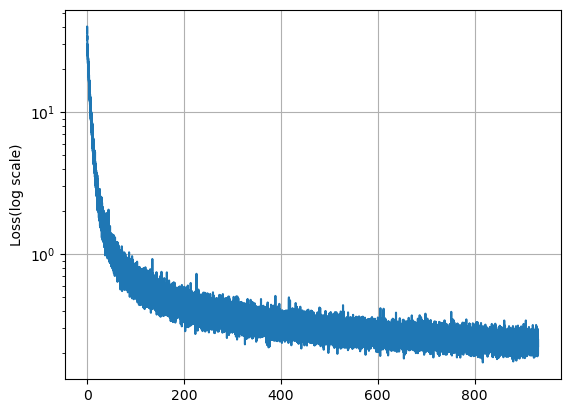

In [53]:
#plt.figure(1, figsize = [20,10])

plt.semilogy(num_samps, epoch_losses)
#plt.semilogy(averaged_epoch_losses)
plt.ylabel('Loss(log scale)')
plt.grid()

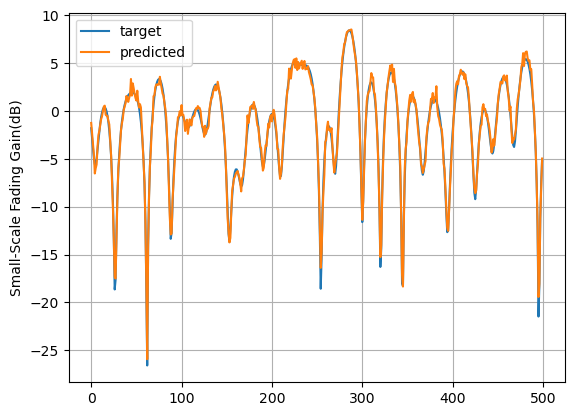

In [37]:
plt.plot(y_test[:,4], alpha = 1, label = 'target')
plt.plot(y_pred[:,4], label = 'predicted')
plt.legend()
plt.ylabel('Small-Scale Fading Gain(dB)')
plt.grid()
plt.show()

In [ ]:
#np.save('working_all_SINRsdB.npy', all_SINRsdB)
